## Imports

In [13]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg
from ageing_packages.hetero_analysis import nhanes_analysis as nhanes
# Fit a Generalized Additive Model (GAM) to the interpolated progeria data
from pygam import LinearGAM, s


import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter, NelsonAalenFitter
import thresholds_functions as th


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Gavrilova Stuff

In [47]:
# Load the Gavrilova CSV files
sis_of_cents_gavrilova = pd.read_csv('saved_results/sis_of_cents_gavrilova.csv')
sis_of_short_lived_gavrilova = pd.read_csv('saved_results/sis_of_short_lived_gavrilova.csv')
bro_of_cents_gavrilova = pd.read_csv('saved_results/bro_of_cents_gavrilova.csv')
bro_of_short_lived_gavrilova = pd.read_csv('saved_results/bro_of_short_lived_gavrilova.csv')

# Rename columns to match expected format and sort by time (high to low)
for df in [sis_of_cents_gavrilova, sis_of_short_lived_gavrilova, bro_of_cents_gavrilova, bro_of_short_lived_gavrilova]:
    df.columns = ['time', 'survival']
    df.sort_values(['time', 'survival'], ascending=[True, True], inplace=True)

# Function to calculate steepness metrics
def calculate_steepness_metrics(df):
    """
    Calculate t25, t50, t75 and steepness for survival data
    """
    time = df['time']  # First column is time
    survival = df['survival']  # Second column is survival
    
    # Create interpolation function
    interp_func = interpolate.interp1d(survival, time, kind='linear', 
                                      bounds_error=False, fill_value='extrapolate')
    
    # Find times for survival thresholds
    t75 = interp_func(0.75)
    t50 = interp_func(0.5)
    t25 = interp_func(0.25)
    
    # Calculate steepness
    steepness = t50 / (t25 - t75)
    
    return {
        't75': t75,
        't50': t50,
        't25': t25,
        'steepness': steepness
    }

# Calculate metrics for each dataset
datasets = {
    'sis_of_cents_gavrilova': sis_of_cents_gavrilova,
    'sis_of_short_lived_gavrilova': sis_of_short_lived_gavrilova,
    'bro_of_cents_gavrilova': bro_of_cents_gavrilova,
    'bro_of_short_lived_gavrilova': bro_of_short_lived_gavrilova
}

gavrilova_results = {}
for name, data in datasets.items():
    gavrilova_results[name] = calculate_steepness_metrics(data)
    print(f"{name}:")
    print(f"  t75: {gavrilova_results[name]['t75']:.3f}")
    print(f"  t50: {gavrilova_results[name]['t50']:.3f}")
    print(f"  t25: {gavrilova_results[name]['t25']:.3f}")
    print(f"  Steepness: {gavrilova_results[name]['steepness']:.3f}")
    print()


sis_of_cents_gavrilova:
  t75: 75.308
  t50: 84.314
  t25: 91.095
  Steepness: 5.341

sis_of_short_lived_gavrilova:
  t75: 69.281
  t50: 78.380
  t25: 85.812
  Steepness: 4.741

bro_of_cents_gavrilova:
  t75: 70.711
  t50: 79.268
  t25: 86.545
  Steepness: 5.006

bro_of_short_lived_gavrilova:
  t75: 64.832
  t50: 73.086
  t25: 80.601
  Steepness: 4.635



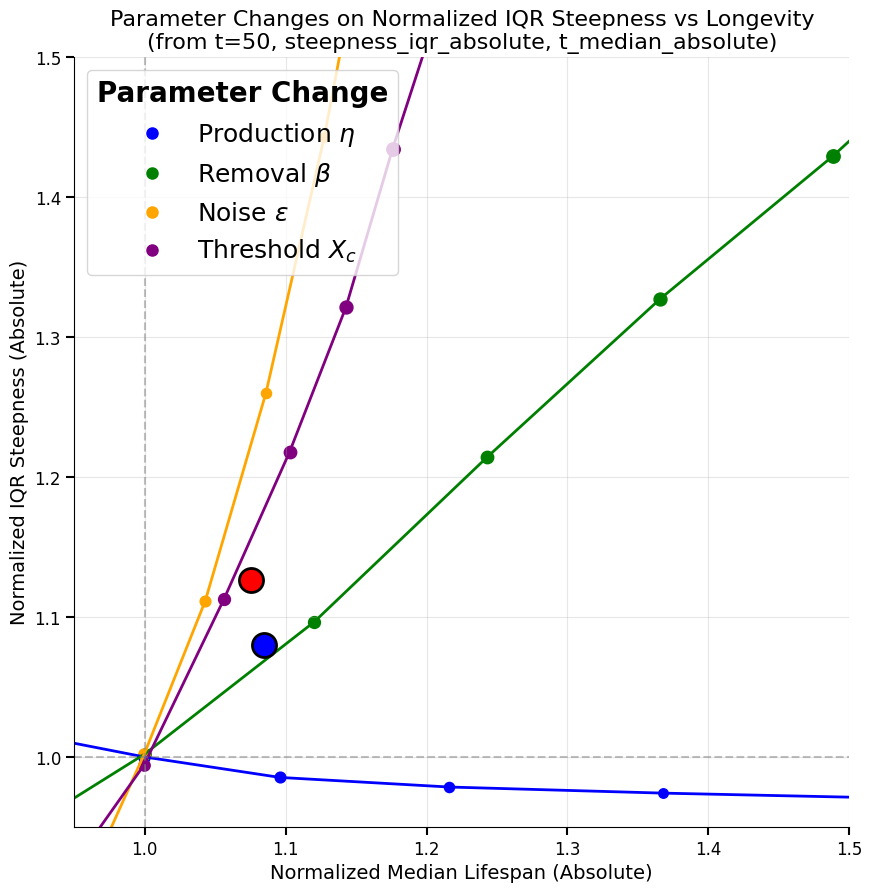

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
th.plot_steepness_longevity(ax=ax, from_t = 50)

# Calculate the scatter point coordinates
x_coord = gavrilova_results['sis_of_cents_gavrilova']['t50'] / gavrilova_results['sis_of_short_lived_gavrilova']['t50']
y_coord = gavrilova_results['sis_of_cents_gavrilova']['steepness'] / gavrilova_results['sis_of_short_lived_gavrilova']['steepness']

# Add the big scatter dot
ax.scatter(x_coord, y_coord, s=300, c='red', marker='o', edgecolors='black', linewidth=2, 
           label='Siblings of Centenarians vs Short-lived', zorder=10)

x_coord = gavrilova_results['bro_of_cents_gavrilova']['t50'] / gavrilova_results['bro_of_short_lived_gavrilova']['t50']
y_coord = gavrilova_results['bro_of_cents_gavrilova']['steepness'] / gavrilova_results['bro_of_short_lived_gavrilova']['steepness']

# Add the big scatter dot
ax.scatter(x_coord, y_coord, s=300, c='blue', marker='o', edgecolors='black', linewidth=2, 
           label='Brothers of Centenarians vs Short-lived', zorder=10)



ax.set_xlim(0.95, 1.5)
ax.set_ylim(0.95, 1.5)










plt.show()

# Loading Data

In [48]:
# Load the CSV files
females_1900 = pd.read_csv('saved_results/females 1900.csv')
males_1900 = pd.read_csv('saved_results/males 1900.csv')
females_sibs_cents = pd.read_csv('saved_results/females sibs of cents.csv')
males_sibs_cents = pd.read_csv('saved_results/males sibs of cents.csv')

# Rename columns to match expected format and sort by time (high to low)
for df in [females_1900, males_1900, females_sibs_cents, males_sibs_cents]:
    df.columns = ['time', 'survival']
    df.sort_values(['time', 'survival'], ascending=[True, True], inplace=True)

# Function to calculate steepness metrics
def calculate_steepness_metrics(df):
    """
    Calculate t25, t50, t75 and steepness for survival data
    """
    time = df['time']  # First column is time
    survival = df['survival']  # Second column is survival
    
    # Create interpolation function
    interp_func = interpolate.interp1d(survival, time, kind='linear', 
                                      bounds_error=False, fill_value='extrapolate')
    
    # Find times for survival thresholds
    t75 = interp_func(0.75)
    t50 = interp_func(0.5)
    t25 = interp_func(0.25)
    
    # Calculate steepness
    steepness = t50 / (t25 - t75)
    
    return {
        't75': t75,
        't50': t50,
        't25': t25,
        'steepness': steepness
    }

# Calculate metrics for each dataset
datasets = {
    'females_1900': females_1900,
    'males_1900': males_1900,
    'females_sibs_cents': females_sibs_cents,
    'males_sibs_cents': males_sibs_cents
}

results = {}
for name, data in datasets.items():
    results[name] = calculate_steepness_metrics(data)
    print(f"{name}:")
    print(f"  t75: {results[name]['t75']:.3f}")
    print(f"  t50: {results[name]['t50']:.3f}")
    print(f"  t25: {results[name]['t25']:.3f}")
    print(f"  Steepness: {results[name]['steepness']:.3f}")
    print()


females_1900:
  t75: 63.761
  t50: 78.483
  t25: 87.734
  Steepness: 3.274

males_1900:
  t75: 57.536
  t50: 70.016
  t25: 80.163
  Steepness: 3.094

females_sibs_cents:
  t75: 76.661
  t50: 88.912
  t25: 96.606
  Steepness: 4.458

males_sibs_cents:
  t75: 68.908
  t50: 80.511
  t25: 90.263
  Steepness: 3.770



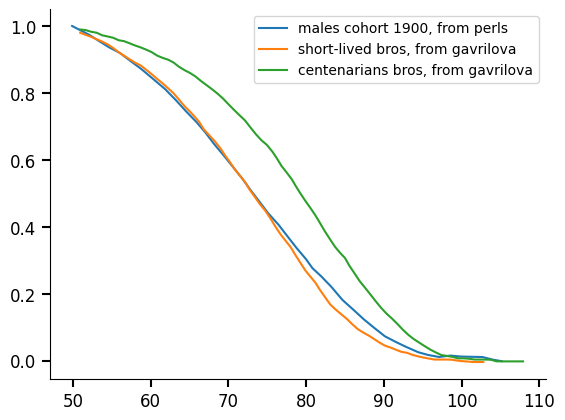

In [52]:
# Find index where time is nearest to 50
idx_50 = np.argmin(np.abs(males_1900['time'] - 50))

# Plot survival from that index, normalized by survival value at that index
time_subset = males_1900['time'][idx_50:]
survival_subset = males_1900['survival'][idx_50:]
survival_normalized = survival_subset / males_1900['survival'].iloc[idx_50]

plt.plot(time_subset, survival_normalized, label = 'males cohort 1900, from perls')
plt.plot(bro_of_short_lived_gavrilova['time'], bro_of_short_lived_gavrilova['survival'], label = 'short-lived bros, from gavrilova')
plt.plot(bro_of_cents_gavrilova['time'], bro_of_cents_gavrilova['survival'], label = 'centenarians bros, from gavrilova')
plt.legend()
plt.show()

In [20]:
def sample_death_times_from_survival(df, n):
    """
    Sample n death times from survival curve by treating survival as 1-CDF
    
    Parameters:
    df: DataFrame with 'time' and 'survival' columns
    n: number of death times to sample
    
    Returns:
    array of sampled death times
    """
    time = df['time'].values
    survival = df['survival'].values
    
    # Convert survival to CDF (cumulative death probability)
    cdf = 1 - survival
    
    # Generate random uniform samples
    u = np.random.uniform(0, 1, n)
    
    # Create interpolation function from CDF to time
    # Use linear interpolation to find times corresponding to CDF values
    interp_func = interpolate.interp1d(cdf, time, kind='linear', 
                                      bounds_error=False, fill_value='extrapolate')
    
    # Sample death times
    death_times = interp_func(u)
    
    return death_times


death_times = sample_death_times_from_survival(females_1900, 50000)






/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/lifelines/fitters/nelson_aalen_fitter.py:246: RuntimeWarning: invalid value encountered in divide
  self.ci_labels[0]: hazard_ * np.exp(z * std_hazard_ / hazard_),
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/lifelines/fitters/nelson_aalen_fitter.py:247: RuntimeWarning: invalid value encountered in divide
  self.ci_labels[1]: hazard_ * np.exp(-z * std_hazard_ / hazard_),
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/lifelines/fitters/nelson_aalen_fitter.py:246: RuntimeWarning: invalid value encountered in divide
  self.ci_labels[0]: hazard_ * np.exp(z * std_hazard_ / hazard_),
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/lifelines/fitters/nelson_aalen_fitter.py:247: RuntimeWarning: invalid value encountered in divide
  self.ci_labels[1]: hazard_ * np.exp(-z * std_hazard_ / hazard_),
/Library/Frameworks/Py

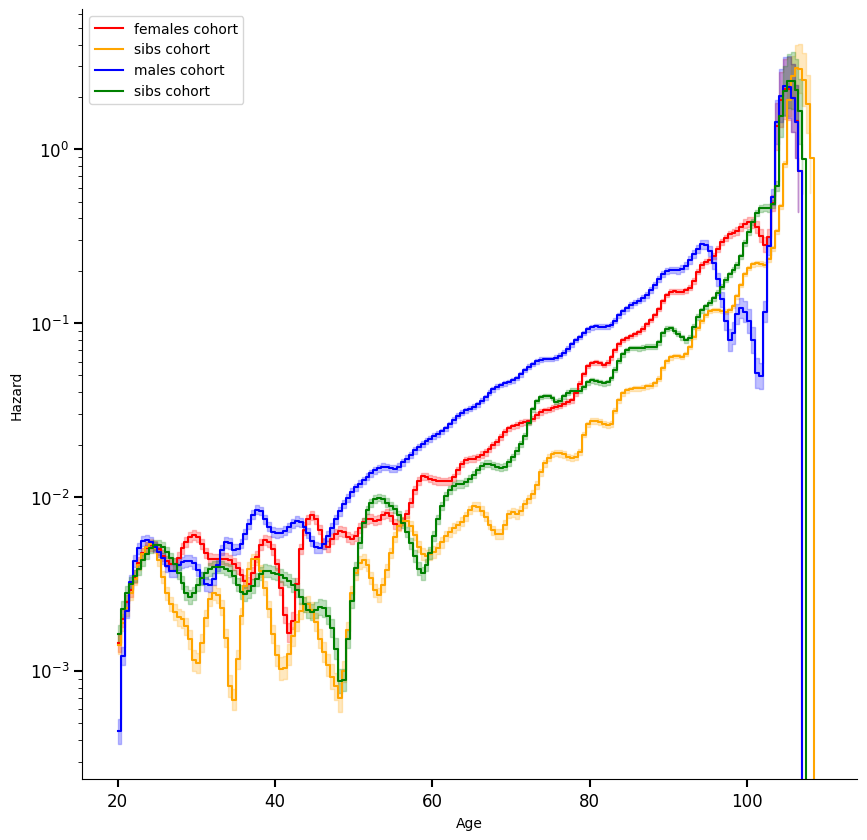

In [32]:
def plot_hazard_from_survival(ax, survival_df, n_samples=50000, bandwidth=3, label = 'None', color = 'blue'):
    """
    Plot hazard function from survival curve data
    
    Parameters:
    ax: matplotlib axis to plot on
    survival_df: DataFrame with survival curve data
    n_samples: number of death times to sample
    bandwidth: bandwidth for hazard smoothing
    """
    # Sample death times from survival curve
    death_times = sample_death_times_from_survival(survival_df, n_samples)
    
    # Fit NAF to death times
    naf = NelsonAalenFitter()
    timeline = np.arange(20, 110, 0.5)
    naf.fit(durations=death_times, event_observed=np.ones(len(death_times)), timeline=timeline)
    
    # Plot hazard
    naf.plot_hazard(ax=ax, bandwidth=2, label = label, color = color)
    ax.set_yscale('log')

# Create figure and plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
plot_hazard_from_survival(ax, females_1900, label = 'females cohort', color = 'red')
plot_hazard_from_survival(ax, females_sibs_cents, label = 'sibs cohort', color = 'orange')
plot_hazard_from_survival(ax, males_1900, label = 'males cohort', color = 'blue')
plot_hazard_from_survival(ax, males_sibs_cents, label = 'sibs cohort', color = 'green')


ax.legend()
ax.set_xlabel('Age')
ax.set_ylabel('Hazard')
plt.show()


## Plotting, with extrinsic

(0.5, 1.4)

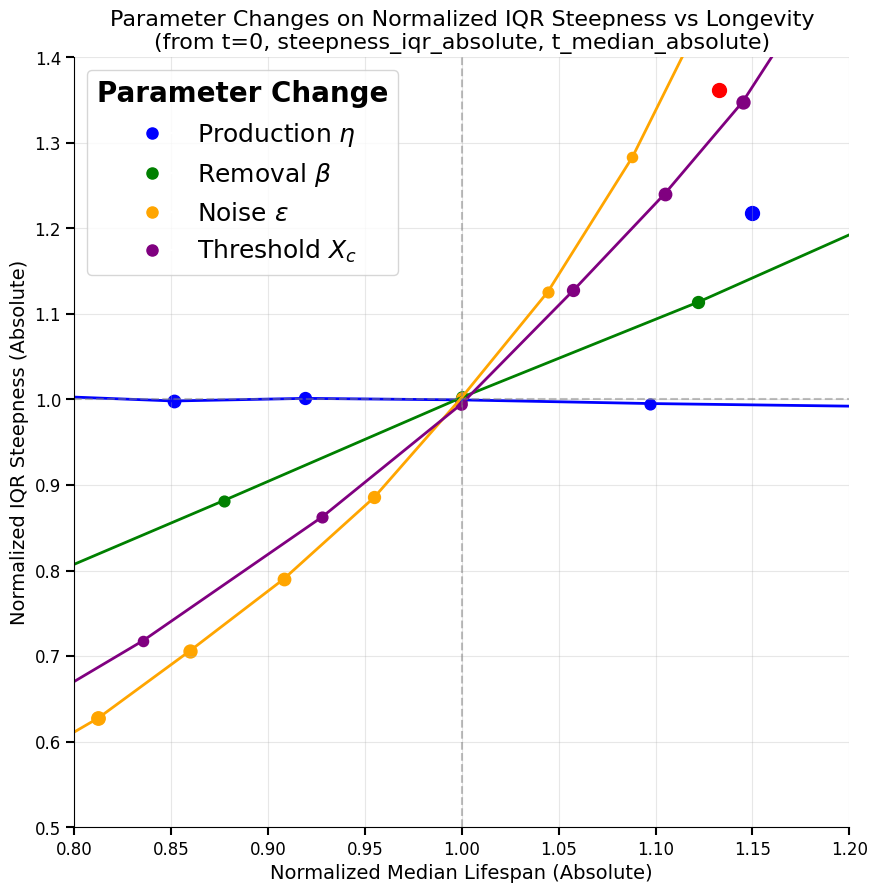

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

th.plot_steepness_longevity(ax=ax)

# Calculate ratios for males
males_t50_ratio = results['males_sibs_cents']['t50'] / results['males_1900']['t50']
males_steepness_ratio = results['males_sibs_cents']['steepness'] / results['males_1900']['steepness']

# Calculate ratios for females
females_t50_ratio = results['females_sibs_cents']['t50'] / results['females_1900']['t50']
females_steepness_ratio = results['females_sibs_cents']['steepness'] / results['females_1900']['steepness']

# Plot scatter points
ax.scatter(males_t50_ratio, males_steepness_ratio, s=100, color='blue', label='Males')
ax.scatter(females_t50_ratio, females_steepness_ratio, s=100, color='red', label='Females')

ax.set_xlim(0.8, 1.2)
ax.set_ylim(0.5, 1.4)
ax.set_title('With extrinsic mortality')


# Removing Extrinsic

Fitted to KMF data:
a:  4.179892739746597e-05
b:  0.08879271444479332
c:  8.999266802894851
m:  0.0022472594965446896
Final MSE: 0.000190
Optimization success: True
Comparison of Males Sibs Cents Results:
Metric       Original     Gamma-Gompertz  Difference  
-------------------------------------------------------
t75          68.908       67.472          -1.435      
t50          80.511       80.581          0.070       
t25          90.263       90.484          0.221       
Steepness    3.770        3.502           -0.268      


{'t75': 67.47237429822236,
 't50': 80.5810726780718,
 't25': 90.48374965985842,
 'steepness': 3.501792978980926}

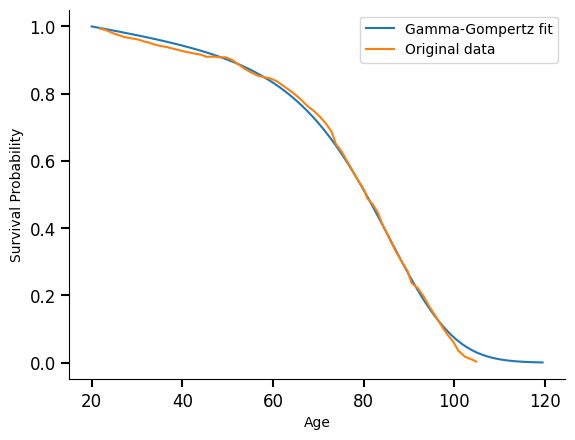

In [88]:
class MockKMF:
    def __init__(self, times, survival_probs):
        self.timeline = np.array(times)
        # Create DataFrame with survival probabilities
        self.survival_function_ = pd.DataFrame(
            survival_probs, 
            index=times, 
            columns=['KM_estimate']
        )

def fit_gamma_gompertz_model(df):
    """
    Fit Gamma-Gompertz model to survival data.
    
    Args:
        df: DataFrame with 'time' and 'survival' columns
        
    Returns:
        gg_model: Fitted Gamma-Gompertz model
    """
    mock_kmf = MockKMF(df.time.values, df.survival.values)
    gg_model = gg()
    gg_model.fit_params(kmf=mock_kmf)
    return gg_model

def plot_gamma_gompertz_fit(df, title=None):
    """
    Plot Gamma-Gompertz fit to survival data with difference plot.
    
    Args:
        df: DataFrame with 'time' and 'survival' columns
        title: Optional title for the plot
    """
    # Fit the model first
    gg_model = fit_gamma_gompertz_model(df)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.plot(df.time.values, df.survival.values, label='Original data')
    gg_model.plot_survival_from_age_X(age_X = 20, ax=ax, label = 'mgg fit')

    # Plot the difference between the two
    times, gg_survival = gg_model.survival_function(df.time.values, gg_model.a, gg_model.b, gg_model.c, gg_model.m)
    diff = df.survival.values - gg_survival
    ax2 = ax.twinx()
    ax2.plot(df.time.values, diff, color='green', linestyle='--', label='Difference (Original - Fit)')
    ax2.set_ylabel('Difference', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    ax.legend(loc='upper right')
    ax2.legend(loc='lower right')
    
    if title:
        ax.set_title(title)
    
    return fig, ax, ax2

def get_gg_metrics(gg_model, from_t=20):
    """
    Calculate median and steepness from Gamma-Gompertz model.
    
    Args:
        gg_model: Fitted Gamma-Gompertz model
        from_t: Starting age for calculations
        
    Returns:
        dict: Dictionary containing t75, t50, t25, and steepness
    """
    time = np.arange(from_t, 120, 0.5)
    time, survival = gg_model.survival_function(time)

    # Find t50, t25, and t75 from survival
    t50_gg = np.interp(0.5, survival[::-1], time[::-1])
    t25_gg = np.interp(0.25, survival[::-1], time[::-1])
    t75_gg = np.interp(0.75, survival[::-1], time[::-1])

    steepness_gg = t50_gg / -(t75_gg - t25_gg)   
    
    return {
        't75': t75_gg,
        't50': t50_gg,
        't25': t25_gg,
        'steepness': steepness_gg
    }

def compare_gamma_gompertz_fit(df, title=None):
    """
    Compare original survival data with Gamma-Gompertz fit and calculate metrics.
    
    Args:
        df: DataFrame with 'time' and 'survival' columns
        title: Optional title for the plot
        
    Returns:
        dict: Dictionary containing comparison metrics
    """
    # Fit the model
    gg_model = fit_gamma_gompertz_model(df)
    time = np.arange(20, 120, 0.5)
    time, survival = gg_model.survival_function(time)

    plt.plot(time, survival, label='Gamma-Gompertz fit')
    plt.plot(df.time.values, df.survival.values, label='Original data')
    plt.legend()
    plt.xlabel('Age')
    plt.ylabel('Survival Probability')
    if title:
        plt.title(title)

    # Get metrics using the new function
    comparison_results = get_gg_metrics(gg_model, from_t=20)
    
    # Get the dataframe name to use as key in results
    df_name = [name for name, obj in globals().items() if obj is df][0] if any(obj is df for obj in globals().values()) else None
    
    # Compare with original results if available
    if df_name and df_name in results:
        print(f"Comparison of {df_name.replace('_', ' ').title()} Results:")
        print("=" * 40)
        print(f"{'Metric':<12} {'Original':<12} {'Gamma-Gompertz':<15} {'Difference':<12}")
        print("-" * 55)
        print(f"{'t75':<12} {results[df_name]['t75']:<12.3f} {comparison_results['t75']:<15.3f} {comparison_results['t75'] - results[df_name]['t75']:<12.3f}")
        print(f"{'t50':<12} {results[df_name]['t50']:<12.3f} {comparison_results['t50']:<15.3f} {comparison_results['t50'] - results[df_name]['t50']:<12.3f}")
        print(f"{'t25':<12} {results[df_name]['t25']:<12.3f} {comparison_results['t25']:<15.3f} {comparison_results['t25'] - results[df_name]['t25']:<12.3f}")
        print(f"{'Steepness':<12} {results[df_name]['steepness']:<12.3f} {comparison_results['steepness']:<15.3f} {comparison_results['steepness'] - results[df_name]['steepness']:<12.3f}")
    
    return comparison_results





# Fit the model and then plot
compare_gamma_gompertz_fit(males_sibs_cents)

## Removing Extrinsic and Plotting

In [89]:
males_gg = fit_gamma_gompertz_model(males_1900)
males_gg.m = 0
males_gg_metrics = get_gg_metrics(males_gg, from_t=20)

males_sibs_gg = fit_gamma_gompertz_model(males_sibs_cents)
males_sibs_gg.m = 0
males_sibs_gg_metrics = get_gg_metrics(males_sibs_gg, from_t=20)




females_gg = fit_gamma_gompertz_model(females_1900)
females_gg.m = 0
females_gg_metrics = get_gg_metrics(females_gg, from_t=20)



females_sibs_gg = fit_gamma_gompertz_model(females_sibs_cents)
females_sibs_gg.m = 0
females_sibs_gg_metrics = get_gg_metrics(females_sibs_gg, from_t=20)



Fitted to KMF data:
a:  4.890636586408947e-05
b:  0.09783346931490182
c:  8.999982413989999
m:  0.0048916591602942375
Final MSE: 0.000066
Optimization success: True
Fitted to KMF data:
a:  4.179892739746597e-05
b:  0.08879271444479332
c:  8.999266802894851
m:  0.0022472594965446896
Final MSE: 0.000190
Optimization success: True
Fitted to KMF data:
a:  5.0847624690139626e-05
b:  0.08850588402653599
c:  8.999467301216164
m:  0.003193116682862148
Final MSE: 0.000223
Optimization success: True
Fitted to KMF data:
a:  3.825233080748024e-05
b:  0.08351969814688621
c:  8.998265457870081
m:  0.0009772215809671332
Final MSE: 0.000750
Optimization success: True


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

females_sibs_gg.plot_survival_from_age_X(age_X = 20, ax=ax, label = 'mgg fit')

females_gg.plot_survival_from_age_X(age_X = 20, ax=ax, label = 'mgg fit')

ax.legend()
ax.set_title('Females 1900')
ax.set_xlabel('Age')
ax.set_ylabel('Survival Probability')
plt.show()

Text(0, 0.5, 'Hazard')

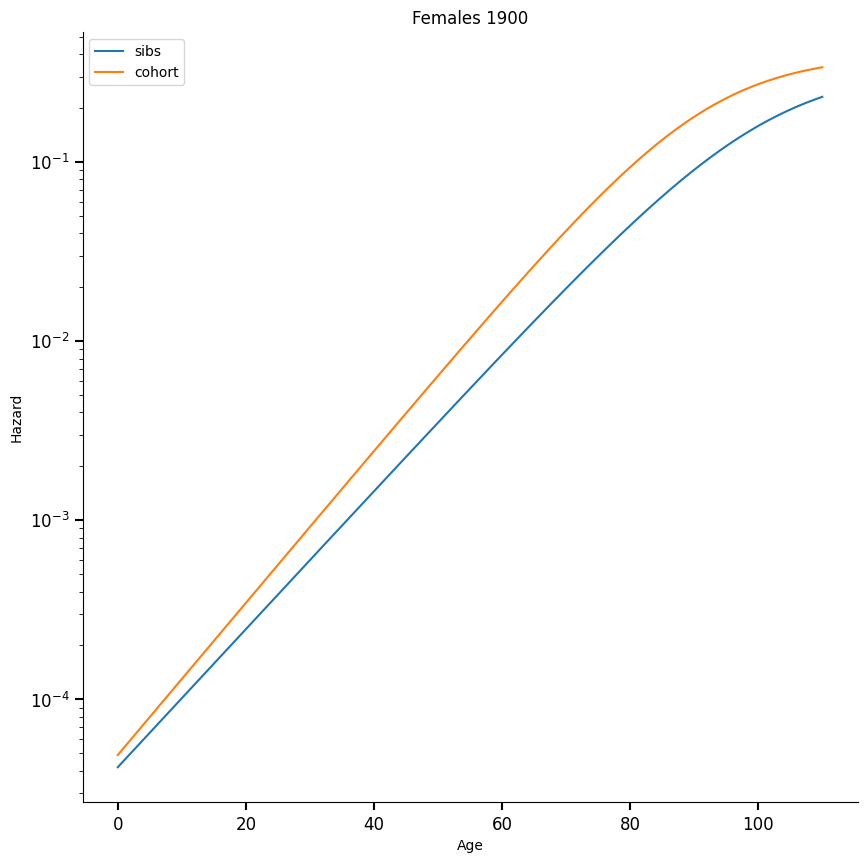

In [92]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

males_sibs_gg.plot_hazard(ax=ax, label = 'sibs')

males_gg.plot_hazard(ax=ax, label = 'cohort')

ax.legend()
ax.set_title('Females 1900')
ax.set_xlabel('Age')
ax.set_ylabel('Hazard')


Text(0.5, 1.0, 'With extrinsic mortality')

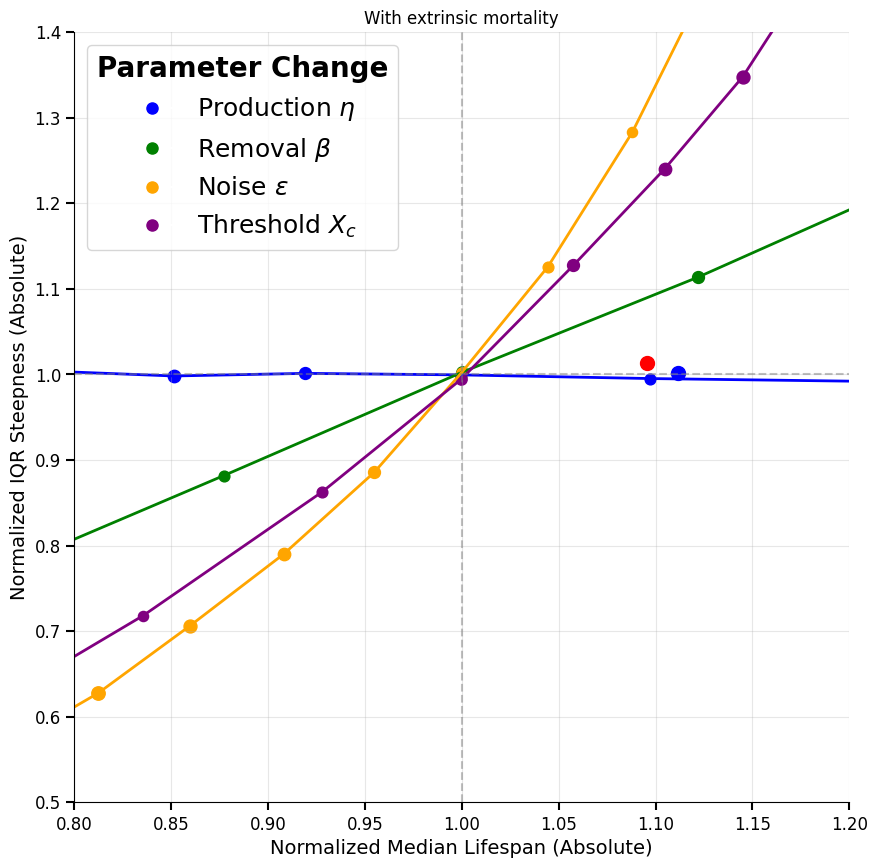

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

th.plot_steepness_longevity(ax=ax)

# Calculate ratios for males
males_t50_ratio = males_sibs_gg_metrics['t50'] / males_gg_metrics['t50']
males_steepness_ratio = males_sibs_gg_metrics['steepness'] / males_gg_metrics['steepness']

# Calculate ratios for females
females_t50_ratio = females_sibs_gg_metrics['t50'] / females_gg_metrics['t50']
females_steepness_ratio = females_sibs_gg_metrics['steepness'] / females_gg_metrics['steepness']

# Plot scatter points
ax.scatter(males_t50_ratio, males_steepness_ratio, s=100, color='blue', label='Males')
ax.scatter(females_t50_ratio, females_steepness_ratio, s=100, color='red', label='Females')

ax.set_xlim(0.8, 1.2)
ax.set_ylim(0.5, 1.4)
ax.set_title('With extrinsic mortality')
